<a href="https://colab.research.google.com/github/SHREYASHSHAURYA/ML-6th-Sem-Lab/blob/main/boostingensemble.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import load_wine
import pandas as pd

# Load the Wine dataset
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target)

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

# Display the first few rows of the features and target
print("\nFirst 5 rows of features (X):")
display(X.head())
print("\nFirst 5 rows of target (y):")
display(y.head())

Features (X) shape: (178, 13)
Target (y) shape: (178,)

First 5 rows of features (X):


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0



First 5 rows of target (y):


,0
0,0
1,0
2,0
3,0
4,0


Next, we will split the dataset into training and testing sets. This is a crucial step to evaluate the model's performance on unseen data and prevent overfitting.

In [ ]:
from sklearn.model_selection import train_test_split

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (142, 13)
X_test shape: (36, 13)
y_train shape: (142,)
y_test shape: (36,)


Now, let's train a Gradient Boosting Classifier, which is a popular Boosting ensemble method. Gradient Boosting builds an ensemble of weak prediction models, typically decision trees, in a stage-wise fashion; it generalizes them by allowing optimization of an arbitrary differentiable loss function.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize the Gradient Boosting Classifier
# n_estimators: Number of boosting stages to perform.
# learning_rate: Shrinks the contribution of each tree by `learning_rate`.
# max_depth: The maximum depth of the individual regression estimators.
gbc_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Train the model on the training data
gbc_model.fit(X_train, y_train)

print("Gradient Boosting Classifier model trained successfully!")

Gradient Boosting Classifier model trained successfully!


Finally, we will evaluate the performance of our trained Gradient Boosting Classifier on the test set using various metrics such as accuracy, classification report, and confusion matrix.

Accuracy: 0.9444

Classification Report:
              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       0.93      0.93      0.93        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.95      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36


Confusion Matrix:


,class_0,class_1,class_2
class_0,12,0,0
class_1,1,13,0
class_2,0,1,9


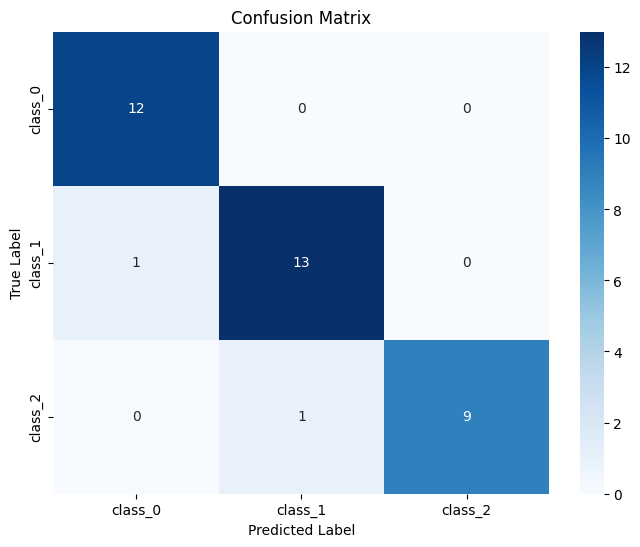

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set
y_pred = gbc_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=wine.target_names))

# Display confusion matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
display(pd.DataFrame(cm, index=wine.target_names, columns=wine.target_names))

# Plot confusion matrix for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()